In [18]:
import sys
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import chi2

sys.path.insert(0, "..")

from sim.core import World, IX, IY, IVX, IVY
from sim.scenarios.loader import build_simulation, load_scenario

N_RUNS = 100


In [19]:
class TrajectoryLogger:
    '''
    This class is specific for this analysis.
    The goal is to use it to store the data for a run and then compute the necessary statistics.
    '''
    def __init__(self, target, ekf):
        self.target = target
        self.ekf = ekf
        self.times = []
        self.true_states = []
        self.est_states = []
        self.covariances = []
    
    def __call__(self, world):
        #we define a callable as this way it is according to our definition of a callack in the World class
        self.times.append(world.clock.t)
        self.true_states.append(self.target.state[:4].copy())   # CV slice
        self.est_states.append(self.ekf.state.copy())
        self.covariances.append(self.ekf.covariance.copy())
    
    def as_arrays(self) -> dict:
        #a dict is good way to have access to everything
        return {
            "t":     np.array(self.times),
            "truth": np.array(self.true_states),
            "est":   np.array(self.est_states),
            "P":     np.array(self.covariances),
        }
    


In [20]:
def run_single(scenario_path: str, seed: int, q_override: float | None = None)-> dict:

    #create the configuration
    config = load_scenario(scenario_path)

    #change seed
    config.radar.seed = seed

    #also change q if needed
    if q_override is not None:
        config.ekf.q = q_override

    world, target, radar, ekf = build_simulation(config)

        #define ekf.predict as a step hook (every tick)
    def step_hook(_world: World) -> None:
        ekf.predict()
    
    #define ekf.update as a measurement hook (every measurement tick), using the last measurement from the radar
    def measurement_hook(_world: World) -> None:
        if radar.last_measurement is not None:
            ekf.update(radar.last_measurement)
    
    #define the logger with the TrajectoryLogger class
    logger = TrajectoryLogger(target, ekf)

    #append all the hooks
    #no render hook, the goal is not to visualize here, is to qunatify performance
    world.on_step_hooks.append(step_hook)
    world.on_step_hooks.append(logger)
    world.on_measurement_hooks.append(measurement_hook)

    #run simulation
    world.run_for(config.world.duration_s)

    #get the dictionary with the logs
    return logger.as_arrays()


In [21]:
#Functions to compute and plot the Root Mean Squared Error (RMSE)

def rmse_positions_per_tick(est, truth):
    err = est - truth
    err = err[:, :, [IX, IY]] # only positions
    err_sq_summed = (err**2).sum(axis=2)  
    mean_err_sq = err_sq_summed.mean(axis=0) 
    return np.sqrt(mean_err_sq)

def rmse_velocities_per_tick(est, truth):
    err = est - truth
    err = err[:, :, [IVX, IVY]]  # only velocities
    err_sq_summed = (err**2).sum(axis=2)
    mean_err_sq = err_sq_summed.mean(axis=0)
    return np.sqrt(mean_err_sq)


def plot_rmse_positions(t, rmse_pos, sigma_r=None):
    #plots RMSE positions in terms of time
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(t, rmse_pos, color="steelblue", linewidth=1.5, label="Position RMSE")
    #we can add the sigma_r line to check if this is converging to the expected value
    if sigma_r is not None:
        ax.axhline(sigma_r, color="tomato", linestyle="--", linewidth=1.2,
                   label=f"$\\sigma_r$ = {sigma_r} m")
    ax.set_ylabel("Position RMSE (m)")
    ax.set_xlabel("Time (s)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.4)
    ax.set_title("EKF Position RMSE over Monte Carlo runs")
    fig.tight_layout()
    plt.show()


def plot_rmse_velocities(t, rmse_vel):
    #just plots RMSE velocities in terms of time
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(t, rmse_vel, color="darkorange", linewidth=1.5, label="Velocity RMSE")
    ax.set_ylabel("Velocity RMSE (m/s)")
    ax.set_xlabel("Time (s)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.4)
    ax.set_title("EKF Velocity RMSE over Monte Carlo runs")
    fig.tight_layout()
    plt.show()


In [26]:
#Functions to compute and plot the Normalized Estimation Error Squared (NEES)

def nees(est, truth, P):

    err = est - truth 
    y = np.linalg.solve(P, err[..., None])[..., 0]
    nees = np.einsum('rti,rti->rt', err, y)
    mean_nees = nees.mean(axis=0)
    return mean_nees

def plot_nees(t, nees, confidence=0.95):
    dof = 4 * N_RUNS
    upper_bound = chi2.ppf(1 - (1 - confidence) / 2, dof) / N_RUNS
    lower_bound = chi2.ppf((1 - confidence) / 2, dof) / N_RUNS

    #trim the first instants, as this value will be very high due to the initial conditions
    t_plot = t[t > 10.0]
    nees_plot = nees[t > 10.0]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(t_plot, nees_plot, color="purple", linewidth=1.5, label="Mean NEES")
    ax.axhline(4.0, color="green", linestyle="--", linewidth=1.2, label="Expected = 4")
    ax.axhline(upper_bound, color="red",   linestyle=":",  linewidth=1.2, label=f"{confidence*100:.0f}% upper = {upper_bound:.2f}")
    ax.axhline(lower_bound, color="blue",  linestyle=":",  linewidth=1.2, label=f"{confidence*100:.0f}% lower = {lower_bound:.2f}")
    ax.fill_between(t_plot, lower_bound, upper_bound, color="tomato", alpha=0.08)
    ax.set_ylabel("Mean NEES")
    ax.set_xlabel("Time (s)")
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.set_title(f"NEES consistency test (4-DOF, {confidence*100:.0f}% band, {N_RUNS} runs)")
    fig.tight_layout()
    plt.show()


In [23]:
results = [run_single("../sim/scenarios/phase1_monte_carlo.yaml", seed) for seed in range(N_RUNS)]

#get the times, same for every run
t = results[0]["t"]

#get the real trajectory, there is no noise in the Target model, same for every run
truth     = np.stack([r["truth"] for r in results])  #shape (N_RUNS, n_ticks, 4)
estimates = np.stack([r["est"] for r in results])  # same shape
P         = np.stack([r["P"] for r in results])  #shape (N_RUNS, n_ticks, 4, 4)

print(f"t:         {t.shape}")
print(f"truth:     {truth.shape}")
print(f"estimates: {estimates.shape}")
print(f"P:         {P.shape}")

t:         (8000,)
truth:     (100, 8000, 4)
estimates: (100, 8000, 4)
P:         (100, 8000, 4, 4)


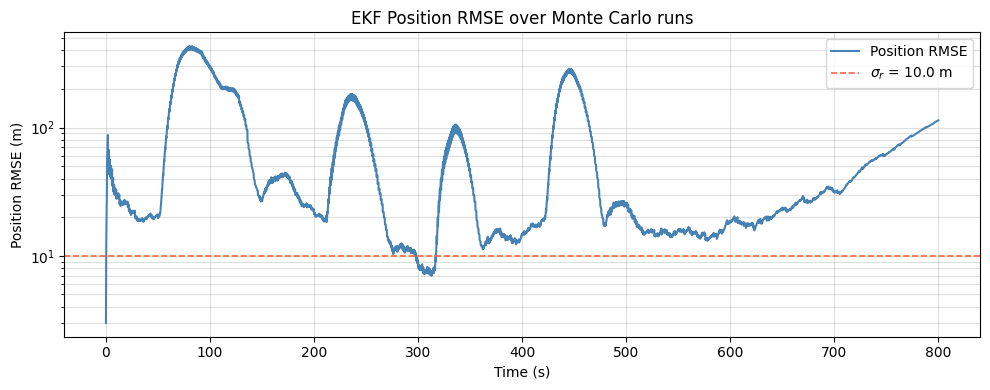

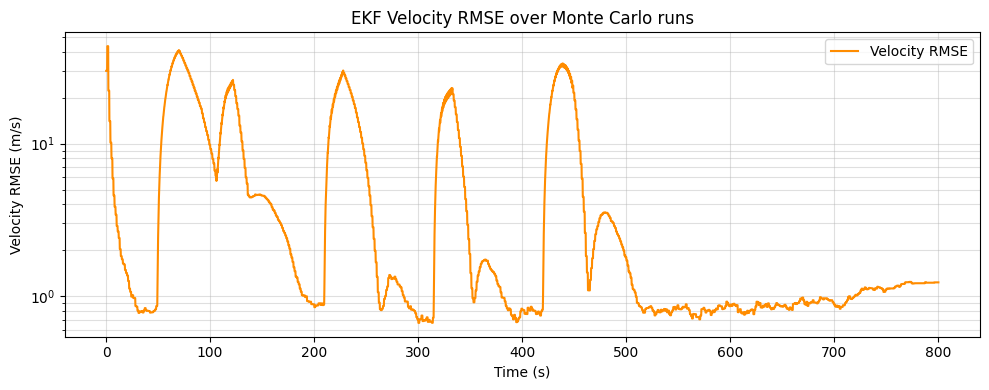

In [24]:
#RMSE plots
rmse_pos = rmse_positions_per_tick(estimates, truth)
rmse_vel = rmse_velocities_per_tick(estimates, truth)

config = load_scenario("../sim/scenarios/phase1_monte_carlo.yaml")
plot_rmse_positions(t, rmse_pos, sigma_r=config.radar.sigma_r)
plot_rmse_velocities(t, rmse_vel)

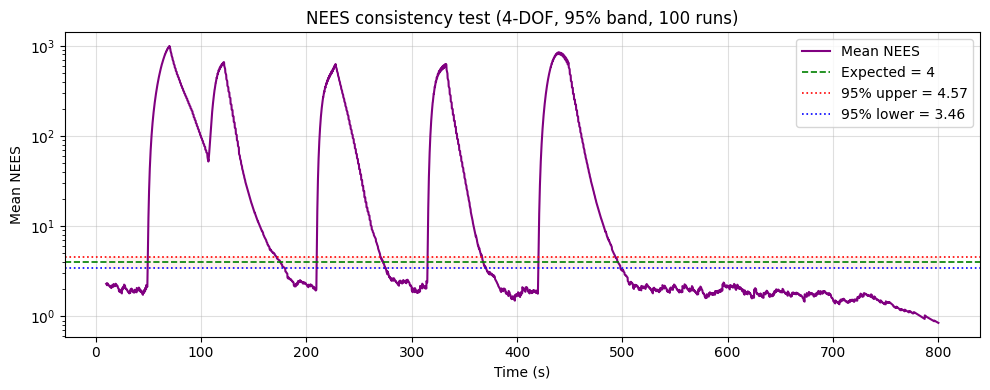

In [27]:
#compute and plot NEES

mean_nees = nees(estimates, truth, P)
plot_nees(t, mean_nees, confidence=0.95)